In [84]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df_raw = pd.read_csv('ML_Data_Insight_121016.csv', header=1) 
cols = ['y','x1', 'x2', 'x3'] 
df_raw.head()

df = df_raw
#df = df_raw.ix[df_raw['y'] < 100]

df.drop_duplicates()

print(np.size(df))

sns.pairplot(df[cols], size=4) 
plt.show()



#df[df['coverage'] > 50]
#df = df_raw


4076


TypeError: pairplot() got an unexpected keyword argument 'bin'

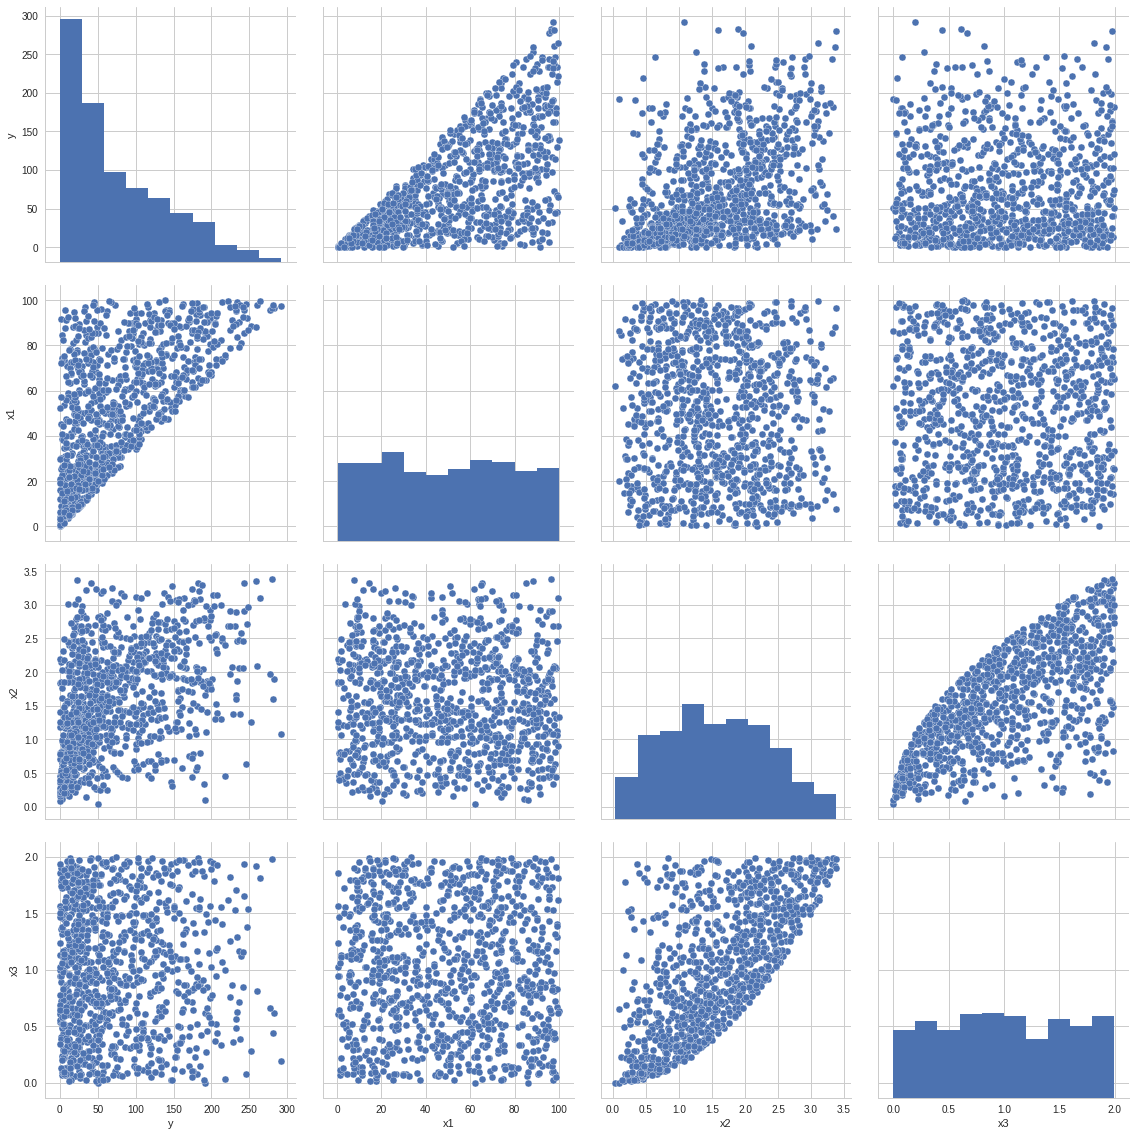

In [74]:

#sns.set(style='whitegrid', context='notebook')

#sns.pairplot(df[cols], size=4)
#plt.show()


In [120]:
print ( df.cov() )
print ( df.corr() )


              y          x1         x2        x3
y   1699.142192  628.773699  11.990487  0.572249
x1   628.773699  738.992180  -3.616040  0.299375
x2    11.990487   -3.616040   0.568985  0.284302
x3     0.572249    0.299375   0.284302  0.324639
           y        x1        x2        x3
y   1.000000  0.561125  0.385631  0.024365
x1  0.561125  1.000000 -0.176345  0.019328
x2  0.385631 -0.176345  1.000000  0.661498
x3  0.024365  0.019328  0.661498  1.000000


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


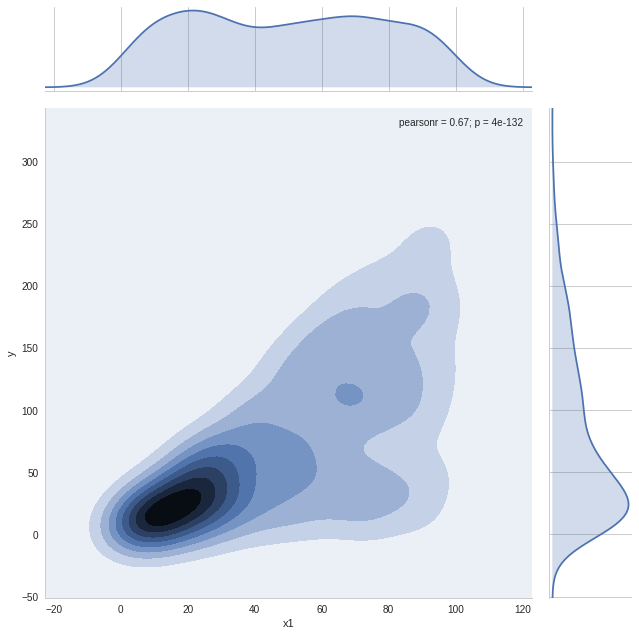

In [181]:
sns.jointplot(x="x1", y="y", data=df, kind="kde", size=9)
plt.show()



/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


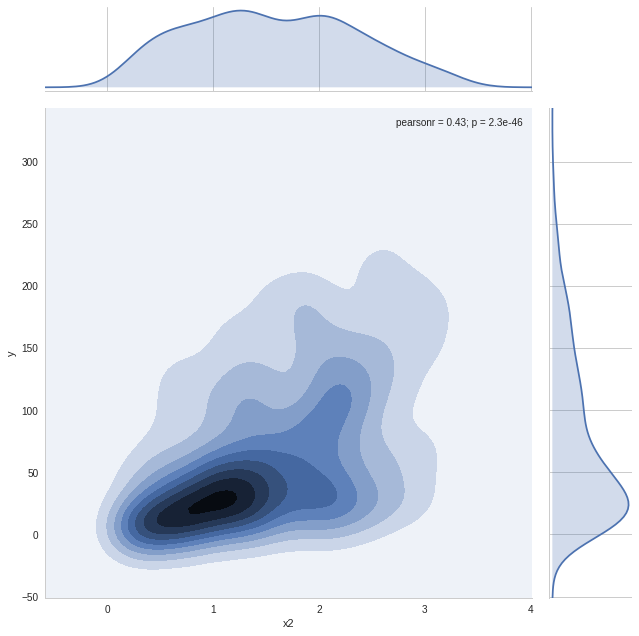

In [178]:
sns.jointplot(x="x2", y="y", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


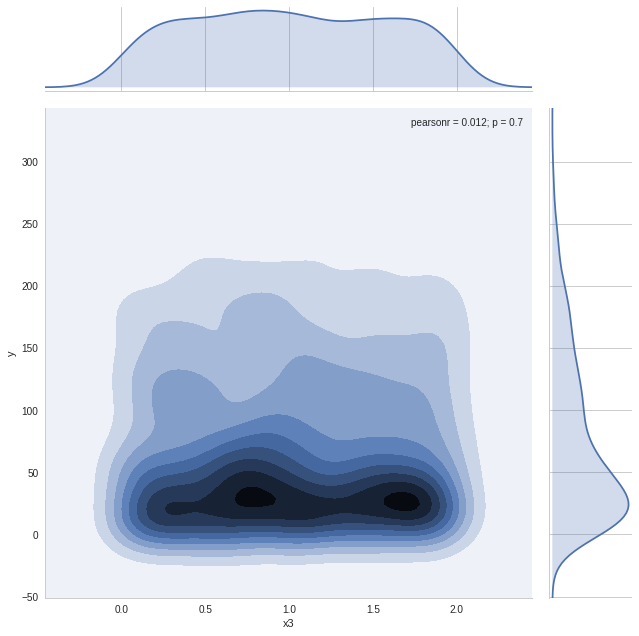

In [182]:
sns.jointplot(x="x3", y="y", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


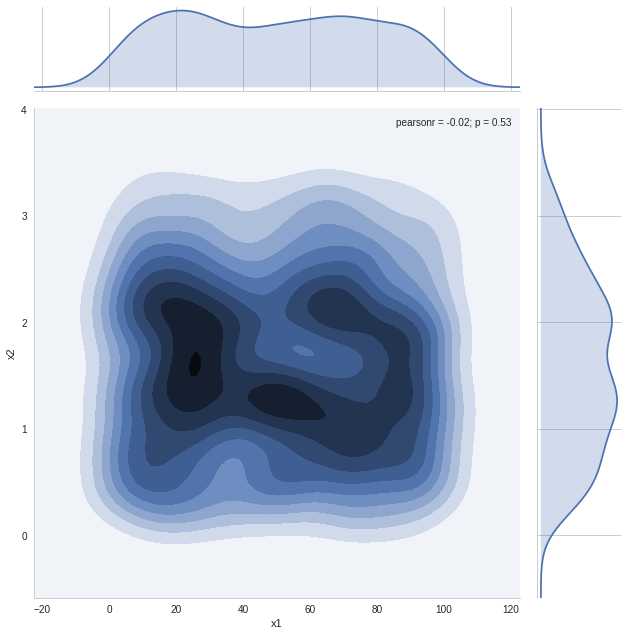

In [183]:
sns.jointplot(x="x1", y="x2", data=df, kind="kde", size=9)
plt.show()


/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


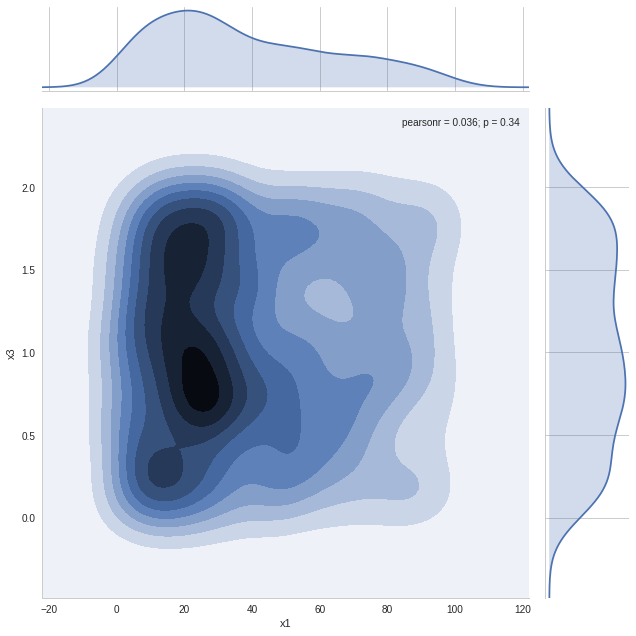

In [175]:
sns.jointplot(x="x1", y="x3", data=df, kind="kde", size=9)
plt.show()

/home/perthi/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:20: VisibleDeprecationWarning: using a non-integer number instead of an integer will result in an error in the future
  y = X[:m/2+1] + np.r_[0,X[m/2+1:],0]*1j


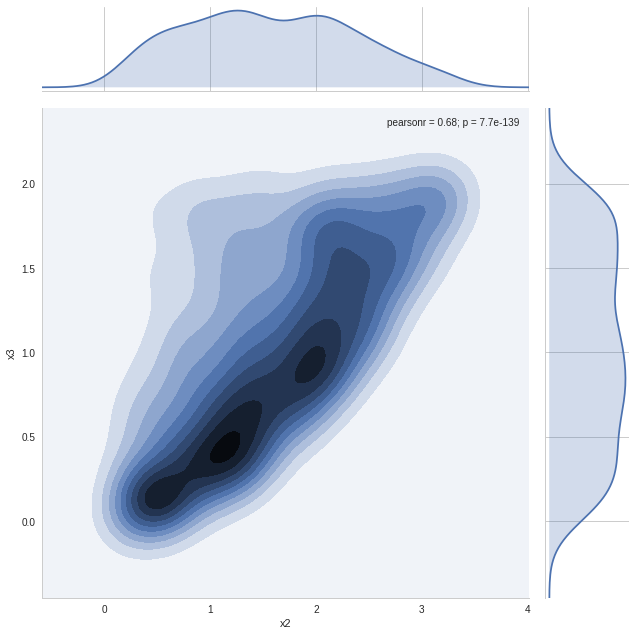

In [184]:
sns.jointplot(x="x2", y="x3", data=df, kind="kde", size=9)
plt.show()

In [92]:
from mpl_toolkits.mplot3d import Axes3D

In [93]:
#fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# Axes3D.contour(X, Y, Z, *args, **kwargs)¶

In [14]:
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale
from collections import Counter

In [71]:
# Prøver lineær regresjon selv om vi ser at sammenhengen er noe mere kompliser for enkelte av variablene. 
# Vi har kun 3 features og ett relativt lite datasett. Det vil si at det kun er 8 mulige
# kombinasjoner av input features: x1, x2, x3, x1x2,x1x3, x2x3 og x1x2x3. (I prinsippet 9
# hvis vi antar att y er uavhengig av all input variable, men vi ser av datasettet at dette ikke er  tilfelle )
# Vi bare prøver oss frem med all mulig kombinasjoner og ser hva som gir best resultat
# Antar att datsettet er u-ordnet. De 800 første rekkene brukes til generering av modell, og de resterenede
# til validering

lm = LinearRegression(normalize=True)

y_train=df.ix[0:800, (0)]
x1x2x3_train=df.ix[0:800, (1,2,3)]
x1x2_train=df.ix[0:800, (1,2)]
x1x3_train=df.ix[0:800, (1,3)]
x2x3_train=df.ix[0:800, (2,3)]
x1_train=df.ix[0:800, (1)]
x2_train=df.ix[0:800, (2)]
x3_train=df.ix[0:800, (3)]

y_val=df.ix[801:, (0)]
x1x2x3_val=df.ix[801:, (1,2,3)]
x1x2_val=df.ix[801:, (1,2)]
x1x3_val=df.ix[801:, (1,3)]
x2x3_val=df.ix[801:, (2,3)]
x1_val=df.ix[801:, (1)]
x2_val=df.ix[801:, (2)]
x3_val=df.ix[801:, (3)]

In [136]:
def fit_linear(X_t, y_t, X_v, y_v, name, height=8):
    g=(np.sqrt(5) +1)/2
    lm.fit(X_t, y_t)
    print ("Model score [0,1] using", name)
    print ("LMS Score for training data:\t", lm.score(X_t, y_t ))
    print ("LMS Score for validation data:\t", lm.score(X_v, y_v )) 
    
    y_pt=lm.predict(X_t)
    y_pt_diff =  y_pt - y_t
    
    y_pv=lm.predict(X_v)
    y_pv_diff =  y_pv - y_v
    
    hmin = min( y_pt.min(),y_pv.min())
    hmax = max( y_pt.max(),y_pv.max())
    plt.figure(1, figsize=(g*height, height))
    plt.scatter(y_pt, y_pt - y_t, c='b', s=40, alpha=0.5)
    plt.scatter(y_pv, y_pv - y_v, c='g', s=40, alpha=0.5)
    plt.hlines(y=0, xmin=hmin, xmax=hmax)
    plt.title('Residual Plot using training data (blue) and test data (green)')
    plt.show()
        

Model score [0,1] using x1, x2, x3
LMS Score for training data:	 0.805415155915
LMS Score for validation data:	 0.767317865862


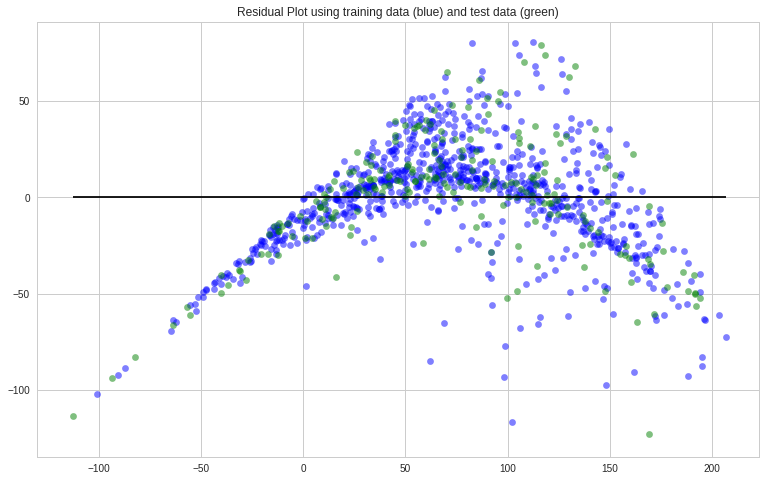

In [137]:
fit_linear(x1x2x3_train, y_train, x1x2x3_val, y_val, 'x1, x2, x3' )

In [ ]:
# Ser av rest plottet at modellen ikke er spesielt god. For en god modell så burde residuen 
# verdien værr normal fordelt med mean = 0. AV formen på residuene så er det nærliggende
# å forsøke en polynom tilpasning, et 2-grads polynom ser ut til å skulle holde.
#Vi ser av det forehåned at vi får best resultat når vi bruker alle featurene x1, x2, x3, så vi bruker denne modellen

Model score [0,1] using x1, x2
LMS Score for training data:	 0.637198017109
LMS Score for validation data:	 0.641323441714


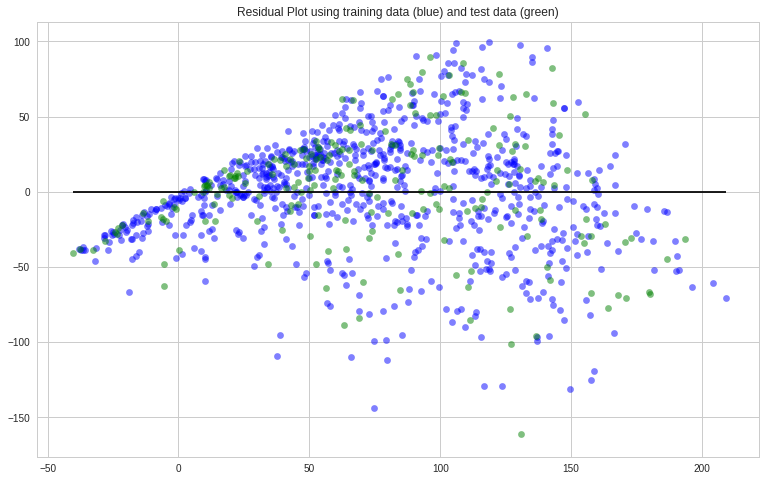

In [138]:
fit_linear(x1x2_train, y_train, x1x2_val, y_val, 'x1, x2' )

0.176882022347
Model score [0,1] using x1, x3
LMS Score for training data:	 0.176882022347
LMS Score for validation data:	 0.213712019258


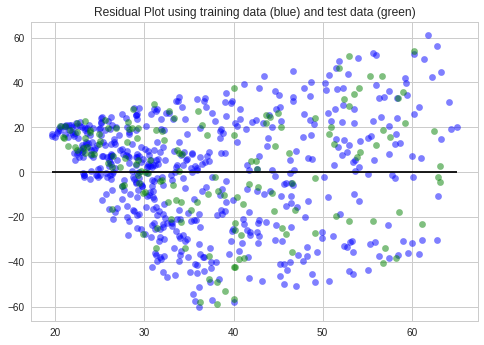

In [60]:
fit_linear(x1x3_train, y_train, x1x3_val, y_val, 'x1, x3' )

0.205281334654
Model score [0,1] using x1, x3
LMS Score for training data:	 0.205281334654
LMS Score for validation data:	 0.185749981141


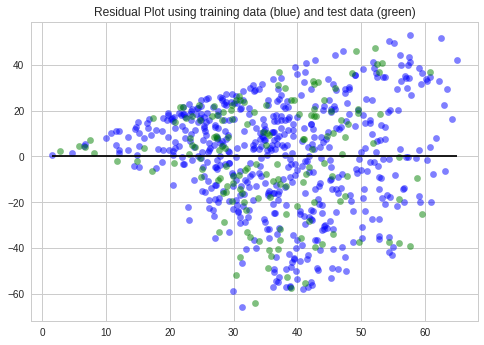

In [61]:
fit_linear(x2x3_train, y_train, x2x3_val, y_val, 'x1, x3' )

0.175081538145
Model score [0,1] using x1
LMS Score for training data:	 0.175081538145
LMS Score for validation data:	 0.22045264891


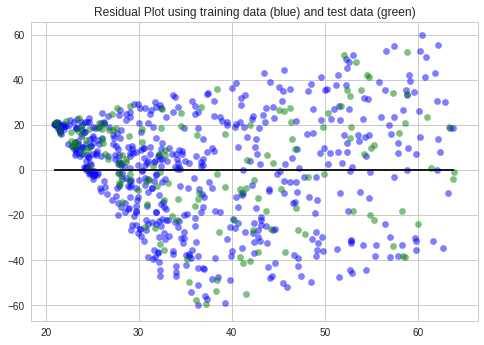

In [64]:
fit_linear(x1_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x1_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x1' )


0.15452931985
Model score [0,1] using x2
LMS Score for training data:	 0.15452931985
LMS Score for validation data:	 0.0789695567926


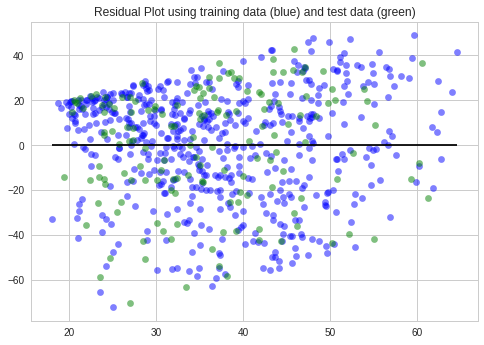

In [65]:
fit_linear(x2_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x2_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x2' )


In [67]:
fit_linear(x3_train.values.reshape(-1,1), y_train.values.reshape(-1,1), x3_val.values.reshape(-1,1), y_val.values.reshape(-1,1), 'x3' )


NameError: name 'fit_linear' is not defined

In [139]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model
import matplotlib.pyplot as plt
from decimal import *

getcontext().prec = 6

def fit_poly(deg, nbins=100, height=8):
    g=(np.sqrt(5) +1)/2
    getcontext().prec = 5
    poly = PolynomialFeatures(degree=deg)
    X_train = poly.fit_transform(x1x2x3_train, (1,2,3))
    X_val   = poly.fit_transform(x1x2x3_val, (1,2,3))
    clf = linear_model.LinearRegression()
    lf = linear_model.LinearRegression()
    clf.fit(X_train, y_train )
    res_train =  clf.predict(X_train) - y_train
    res_val = clf.predict(X_val) - y_val
   # plt.subplot(111)
    plt.figure(1, figsize=(g*height, height))
    plt.scatter(clf.predict(X_train), res_train, c='b', s=40, alpha=0.5)
    plt.scatter(clf.predict(X_val), res_val, c='g', s=40, alpha=0.5)
    #plt.hlines(y=0, xmin=-130, xmax=210)
   
    plt.title('Residual plot som viser trenings data (blå) og validerings data (grønn)')
    print ("Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad", deg)
    print ("LMS Score for treningsdata:\t%0.4f" % clf.score(X_train, y_train ))
    print ("LMS Score for validerings data:\t%0.4f" % clf.score(X_val, y_val ))
   # plt.figure(2, figsize=(16,8))
    plt.figure(2, figsize=(g*height, height))
    plt.hist(res_train, bins=nbins)
    plt.hist(res_val, bins=nbins)
    
    
    print("Training data residuals std:\t%0.4f" % np.std(res_train))
    print("Training data mean:\t\t%0.4f" % np.mean(res_train))
    print("Validation data residuals std:\t%0.4f" % np.std(res_val))
    print("Validation data mean:\t\t%0.4f" % np.mean(res_val))    
  #  plt.figure(3) 
    plt.show()

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 2
LMS Score for treningsdata:	0.9500
LMS Score for validerings data:	0.9454
Training data residuals std:	14.3068
Training data mean:		0.0000
Validation data residuals std:	15.0656
Validation data mean:		2.2633


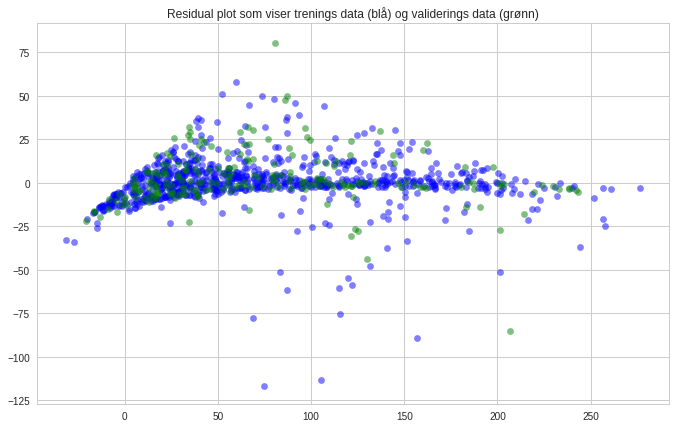

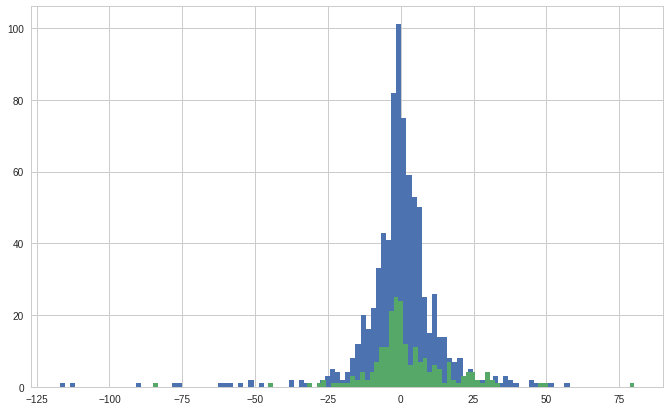

In [133]:
getcontext().prec = 6
fit_poly(2, 100, 7)

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 3
LMS Score for treningsdata:	0.9746
LMS Score for validerings data:	0.9767
Training data residuals std:	10.1904
Training data mean:		0.0000
Validation data residuals std:	9.9276
Validation data mean:		0.6298


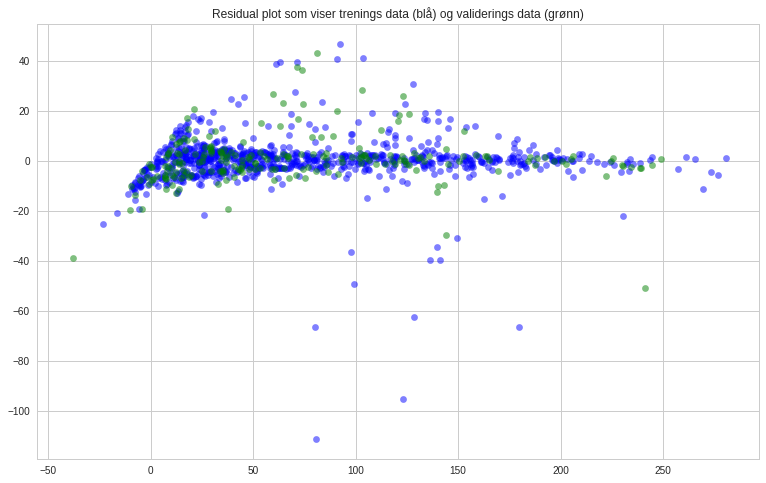

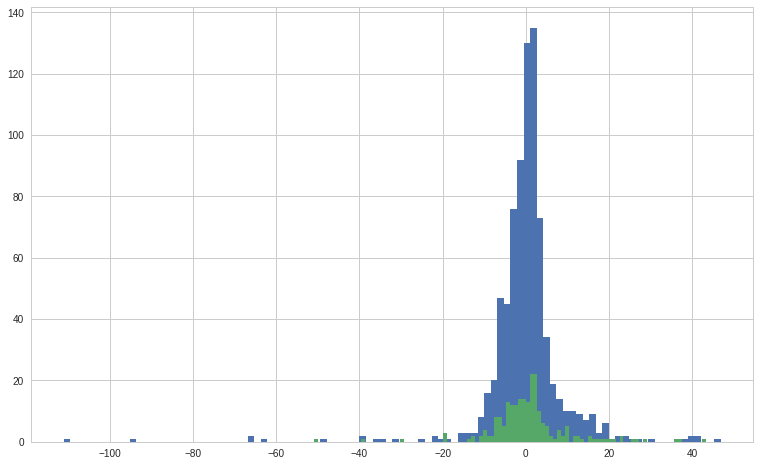

In [140]:
fit_poly(3)

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 4
LMS Score for treningsdata:	0.9841
LMS Score for validerings data:	0.9862
Training data residuals std:	8.0714
Training data mean:		-0.0000
Validation data residuals std:	7.6261
Validation data mean:		0.6792


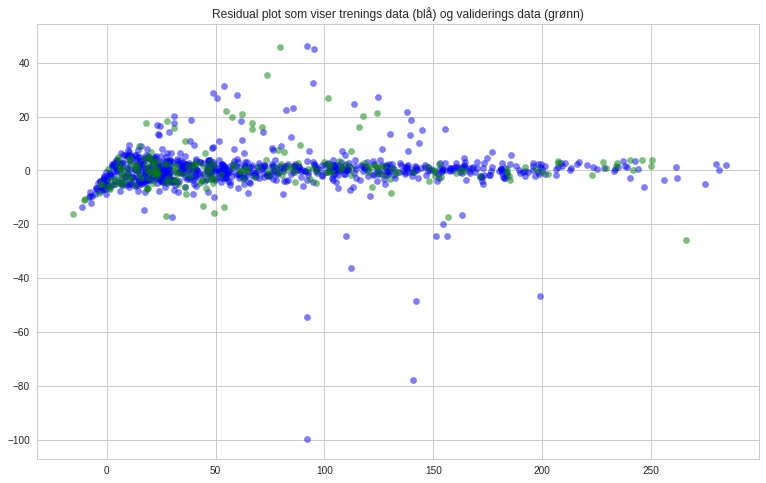

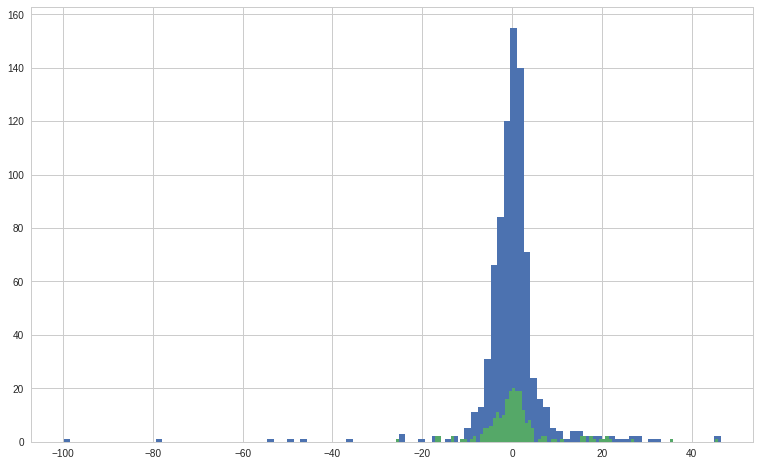

In [141]:
fit_poly(4)


Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 5
LMS Score for treningsdata:	0.9896
LMS Score for validerings data:	0.9917
Training data residuals std:	6.5372
Training data mean:		0.0000
Validation data residuals std:	5.9236
Validation data mean:		0.0516


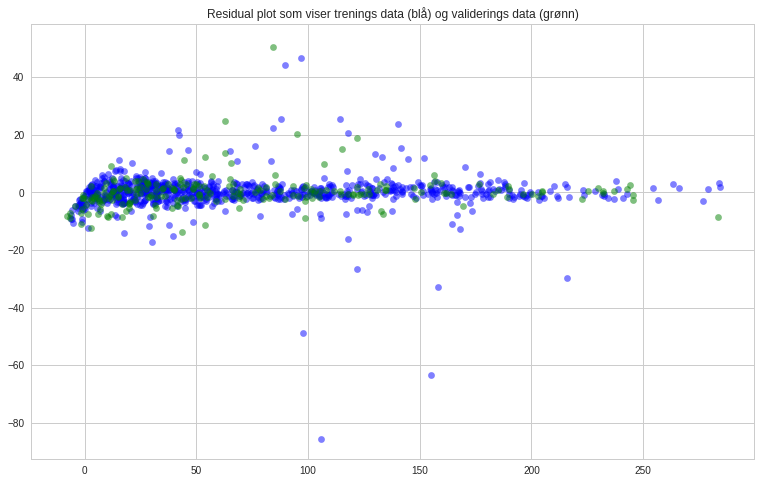

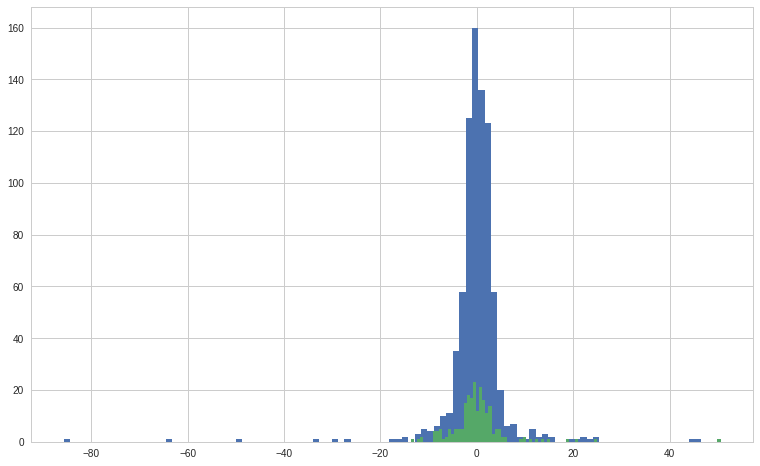

In [142]:
fit_poly(5)

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 6
LMS Score for treningsdata:	0.9930
LMS Score for validerings data:	0.9926
Training data residuals std:	5.3432
Training data mean:		0.0000
Validation data residuals std:	5.5948
Validation data mean:		0.3991


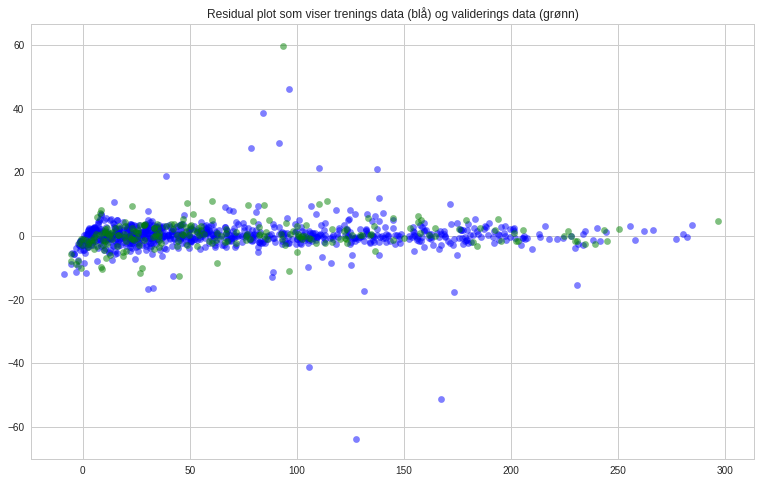

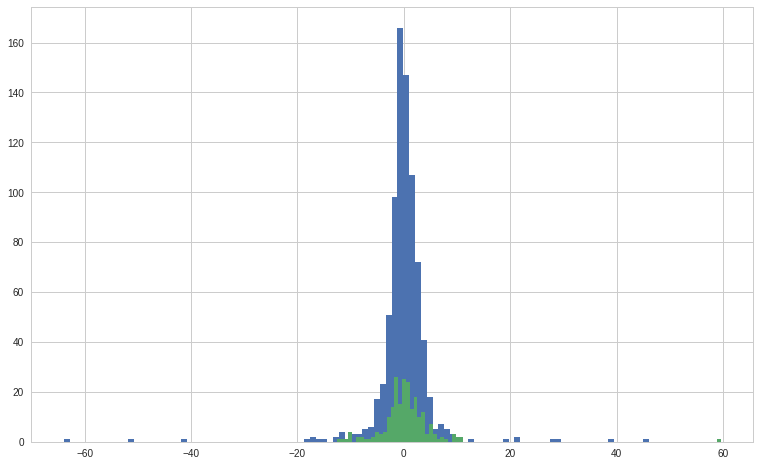

In [143]:
fit_poly(6) 
#dette ser rimelig greit ut, hvis man går høyre opp i polynomgrad så risikerer mant 2 ting. 
# 1) Løsningen blir numerisk ustabil
# 2) anall frihetsgrader øker så my at løsningen fort kan ta seg en tur innom outlierne
# må huske på at med n=6 så får vi ikke bare 3x8 = 18 frihetsgrader, men også alle kryss porduktene

Model score [0,1] med x1,x2,x3 som input og en lineariserende polynom transformasjon av grad 7
LMS Score for treningsdata:	0.9570
LMS Score for validerings data:	0.8767
Training data residuals std:	13.2678
Training data mean:		-0.0000
Validation data residuals std:	22.8494
Validation data mean:		1.3651


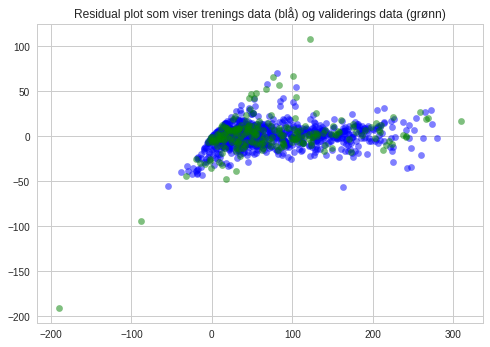

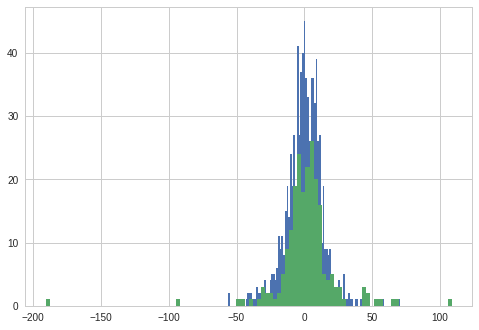

In [204]:
fit_poly(7)
# Går vi høyer oppe en n=6 så får vi problemer med overfitting